# 🚀 Guia Definitivo: Python Multiplataforma (Colab, Windows, Mac) e VS Code

Este notebook é um guia prático e demonstrativo criado para ensinar as melhores práticas de desenvolvimento multiplataforma. Ele foi otimizado para rodar perfeitamente em diferentes ambientes, como o **Google Colab (Linux)**, sua máquina local com **Windows (via VS Code)**, ou **macOS**.

**O que você vai aprender e testar aqui:**
1. 💻 **Comandos Multiplataforma:** Como usar bibliotecas nativas do Python (`os`, `sys`, `platform`) em vez de comandos de terminal que só funcionam em um sistema operacional.
2. 📦 **Gerenciamento de Dependências:** A diferença entre instalar pacotes Python (`pip`) e pacotes do sistema operacional (`apt-get`).
3. 📂 **Manipulação de Arquivos e Caminhos:** Como garantir que seu código encontre e crie pastas com segurança usando `os.path` e `pathlib`.
4. 🖼️ **Trabalhando com Imagens:** Como baixar e exibir imagens de forma segura e universal através de scripts Python.
5. 🔗 **Integração VS Code <-> Colab:** Dicas de como fazer upload e download de arquivos quando conectado a um ambiente remoto.
6. 📊 **Análise de Dados:** Como estruturar e visualizar informações usando DataFrames do `pandas`.

In [1]:
import sys

print("Olá do ambiente Colab!")
print(f"Versão do Python: {sys.version}")


Olá do ambiente Colab!
Versão do Python: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]


### Verificando a Conta Google Autenticada no Ambiente

Podemos usar o `gcloud` CLI (Command Line Interface) para verificar qual conta Google está autenticada no ambiente de execução do Colab. Isso é útil para garantir que estamos usando a conta correta (com Colab Pro, por exemplo).

O comando `gcloud config get-value account` mostra a conta atualmente ativa.

In [ ]:
# Runs the command to check the active account.
# If the result is "(unset)", no account is authenticated for gcloud CLI.
# In that case, open a Colab terminal in VS Code and run:
# gcloud auth login
# After authenticating in the terminal, run this cell again to confirm.
!gcloud config get-value account


joao.petreche@gmail.com


## 🐧 Explorando o Ambiente Linux (Google Colab)

Como o Google Colab roda sobre **Ubuntu (Linux)**, podemos usar o Python para interagir com o sistema operacional.
Abaixo, vamos identificar a distribuição Linux e verificar recursos de hardware.

In [22]:
import os
import subprocess
import sys

def get_system_metadata():
    """
    Fetches Linux distribution details and kernel version.
    Follows Google Automation course best practices for subprocess.
    """
    print("--- Detalhes do Sistema Linux ---")

    # Check if the environment is actually Linux before running Linux-specific commands
    if not sys.platform.startswith('linux'):
        print("⚠️ Este ambiente não é Linux (provavelmente Windows ou Mac local).")
        print("Pulando a execução de comandos específicos do Ubuntu/Colab para evitar erros.")
        return

    # 1. Get Kernel version using 'os'
    kernel_version = os.uname().release
    print(f"Versão do Kernel: {kernel_version}")

    # 2. Get Distribution info using 'subprocess' to read /etc/os-release
    # /etc/os-release is a standard Linux system file; no configurable path needed
    try:
        # 'capture_output=True' allows us to store the result in a variable
        result = subprocess.run(['cat', '/etc/os-release'],
                                capture_output=True,
                                text=True,
                                check=True)
        print("\nInformações da Distribuição:")
        print(result.stdout)
    except FileNotFoundError:
        print("Erro: /etc/os-release não encontrado. Este é um sistema Linux?")
    except subprocess.CalledProcessError as e:
        print(f"O comando falhou com o erro: {e}")

get_system_metadata()


--- Detalhes do Sistema Linux ---
⚠️ Este ambiente não é Linux (provavelmente Windows ou Mac local).
Pulando a execução de comandos específicos do Ubuntu/Colab para evitar erros.


## 📂 Manipulação de Caminhos e Arquivos

No Linux, usamos `/`. No Windows, `\`. O Python resolve isso com `os.path.join()`.
Vamos criar uma estrutura de pastas temporária para simular um sistema de logs.

In [3]:
import os

def setup_test_environment():
    """
    Creates a temporary directory structure safely.
    Uses relative paths to remain cross-platform.
    """
    # Define a target folder in the current workspace
    base_dir = "automation_test"
    logs_dir = os.path.join(base_dir, "logs")

    try:
        # 'exist_ok=True' prevents error if folder already exists
        os.makedirs(logs_dir, exist_ok=True)
        print(f"Criado com sucesso: {logs_dir}")

        # Create a dummy log file
        file_path = os.path.join(logs_dir, "sample.log")
        with open(file_path, "w", encoding="utf-8") as f:
            f.write("System status: OK\nSession started.")

        print(f"Arquivo de exemplo criado em: {file_path}")

    except PermissionError:
        print("Erro: Permissão negada ao criar pastas.")
    except Exception as e:
        print(f"Ocorreu um erro inesperado: {e}")

setup_test_environment()

Criado com sucesso: automation_test\logs
Arquivo de exemplo criado em: automation_test\logs\sample.log


### 💻 Comandos de Sistema Multiplataforma

Dependendo do sistema operacional em que o seu notebook ou script está rodando, os comandos de terminal (`shell`) mudam.
A célula de código abaixo demonstra como lidar com isso:
1. **Forma Universal (Python):** Utiliza bibliotecas nativas como `os` para listar arquivos de forma que funcione em qualquer sistema.
2. **Forma Linux/Mac:** Executa comandos como `pwd` e `ls -la` de forma segura, verificando o sistema operacional (`sys.platform`) antes.
3. **Forma Windows:** Demonstra quais seriam os comandos equivalentes (`cd`, `dir`), prevenindo erros ao rodar no ambiente Linux do Colab.

In [15]:
import os
import sys

# 1. Cross-platform way (Python - Runs on Linux, Mac, and Windows)
print("--- [Python] Diretório de trabalho atual ---")
current_directory = os.getcwd()
print(current_directory)

print("\n--- [Python] Listando arquivos e pastas ---")
# Lists items in the current directory using Python
for item in os.listdir(current_directory):
    print(f" - {item}")

# 2. Linux-specific commands (Google Colab uses Linux)
print("\n--- [Linux] Diretório atual e listagem de arquivos ---")
if sys.platform.startswith('linux') or sys.platform == 'darwin':
    !pwd
    !ls -la
else:
    print("Comandos 'pwd' e 'ls -la' ignorados (o ambiente não é Linux/Mac).")

# 3. Windows-specific commands
print("\n--- [Windows] Diretório atual e listagem de arquivos ---")
if sys.platform == 'win32':
    # In a local Windows environment, these commands would work in Jupyter cells:
    !cd
    !dir
else:
    print("Ambiente atual não é Windows. Os comandos abaixo dariam erro se executados aqui:")
    print(" > !cd  (Para mostrar o diretório atual no Windows)")
    print(" > !dir (Para listar os arquivos no Windows)")

--- [Python] Diretório de trabalho atual ---
c:\Users\joaop\Documents\Google-Automation-Labs

--- [Python] Listando arquivos e pastas ---
 - .git
 - .github
 - .gitignore
 - .venv
 - .vscode
 - automation_test
 - demo.ipynb
 - demo.md
 - demo_web.ipynb
 - hello_world.py
 - MCMV.png
 - README.md
 - requirements.txt
 - setup.ps1
 - setup_and_edit.sh
 - system_health_check.py

--- [Linux] Diretório atual e listagem de arquivos ---
Comandos 'pwd' e 'ls -la' ignorados (o ambiente não é Linux/Mac).

--- [Windows] Diretório atual e listagem de arquivos ---
c:\Users\joaop\Documents\Google-Automation-Labs
 O volume na unidade C n�o tem nome.
 O N�mero de S�rie do Volume � 6871-9C71

 Pasta de c:\Users\joaop\Documents\Google-Automation-Labs

18/04/2026  09:25    <DIR>          .
17/04/2026  10:50    <DIR>          ..
17/04/2026  05:34    <DIR>          .github
17/04/2026  05:34               123 .gitignore
17/04/2026  05:38    <DIR>          .venv
17/04/2026  05:34    <DIR>          .vscode
18/0

### 💻 Verificando as Informações do Sistema Operacional

Podemos obter detalhes sobre o sistema operacional onde o código está rodando.
* **Python:** O módulo `platform` permite obter essas informações em qualquer SO.
* **Linux (Colab):** Comandos nativos como `lsb_release` detalham a distribuição Ubuntu.
* **Windows:** Comandos do CMD como `ver` podem ser usados localmente.

In [16]:
import sys
import platform

# 1. Cross-platform way (Python)
print("--- [Python] Informações do Sistema Operacional ---")
print(f"Sistema: {platform.system()} {platform.release()}")
print(f"Versão detalhada: {platform.platform()}")

# 2. Linux-specific commands
print("\n--- [Linux] Detalhes da Distribuição ---")
if sys.platform.startswith('linux'):
    !lsb_release -a
else:
    print("Ambiente não é Linux. Comando 'lsb_release' ignorado.")

# 3. Windows-specific commands
print("\n--- [Windows] Informações do Sistema ---")
if sys.platform == 'win32':
    !ver
else:
    print("Ambiente atual não é Windows. Comando 'ver' ignorado.")

--- [Python] Informações do Sistema Operacional ---
Sistema: Windows 11
Versão detalhada: Windows-11-10.0.26200-SP0

--- [Linux] Detalhes da Distribuição ---
Ambiente não é Linux. Comando 'lsb_release' ignorado.

--- [Windows] Informações do Sistema ---

Microsoft Windows [vers�o 10.0.26200.8246]


### 📦 Gerenciamento de Pacotes: Nível do Sistema vs. Python

Ao preparar nosso ambiente, podemos precisar instalar dependências de duas formas diferentes, dependendo do escopo:

1.  **Nível Python (Forma Universal):** Usamos o `pip`. Ele instala bibliotecas puramente em Python (como `pandas`, `requests`, `Pillow`) e funciona exatamente da mesma forma no Linux, Mac e Windows.
2.  **Nível de Sistema (Específico por SO):**
    *   **Linux (Colab):** Usamos o gerenciador de pacotes da distribuição (como o `apt-get` no Ubuntu) para instalar dependências do sistema operacional (ex: bibliotecas em C, compiladores, ou binários de sistema).
    *   **Windows/Mac:** Usaríamos ferramentas como `winget`, `choco` ou `brew` (que não se aplicam ao ambiente do Colab).

In [17]:
import sys

# 1. Universal Python package installation
print("--- [Python/Multiplataforma] Instalação via pip ---")
# pip works the same way on Linux, Mac, and Windows
# The '-q' (quiet) flag silences long installation messages
!pip install Pillow -q
print("Biblioteca Pillow verificada/instalada com sucesso via pip.")

# 2. OS-level package installation on Linux
print("\n--- [Linux] Instalação de pacotes de sistema (via apt-get) ---")
if sys.platform.startswith('linux'):
    # We use apt-get instead of apt in scripts, as it is more stable for automation
    !sudo apt-get update -qq
    !sudo apt-get install python3-pil -y -qq
    print("Pacote de sistema 'python3-pil' instalado com sucesso.")
else:
    print("Ambiente não é Linux. Instalação via 'apt-get' ignorada.")

# 3. Note about system packages on Windows
print("\n--- [Windows] Gerenciadores de pacote de sistema ---")
if sys.platform == 'win32':
    print("No Windows, usaríamos comandos do sistema ou ferramentas como 'winget' para dependências do SO.")
else:
    print("Ambiente atual não é Windows. Instruções específicas de Windows puladas.")

--- [Python/Multiplataforma] Instalação via pip ---
Biblioteca Pillow verificada/instalada com sucesso via pip.

--- [Linux] Instalação de pacotes de sistema (via apt-get) ---
Ambiente não é Linux. Instalação via 'apt-get' ignorada.

--- [Windows] Gerenciadores de pacote de sistema ---
No Windows, usaríamos comandos do sistema ou ferramentas como 'winget' para dependências do SO.


### 📂 Manipulando Arquivos no VS Code (Windows <-> Colab)

A extensão Colab para VS Code permite gerenciar arquivos entre o seu ambiente local (Windows) e o ambiente de execução remoto do Colab (Linux) diretamente pelo explorador de arquivos.

**Upload (Windows -> Colab):**
Para enviar um arquivo do seu computador para o Colab:
1. No explorador de arquivos nativo do VS Code, localize o arquivo que você quer usar.
2. Clique com o botão direito do mouse no arquivo e escolha `Upload to Colab`.
3. O arquivo será copiado para o diretório de trabalho atual do Colab (geralmente `/content`).

**Download (Colab -> Windows):**
Para baixar um arquivo gerado no ambiente Colab para o seu PC:
1. Abra o painel lateral do VS Code e expanda a seção `COLAB:CONTENTS`.
2. Clique com o botão direito no arquivo desejado e selecione `Download`.
3. Escolha a pasta no seu Windows onde o arquivo será salvo.

Para mais detalhes, consulte o [Guia do Usuário da extensão Colab para VS Code](https://github.com/googlecolab/colab-vscode/wiki/User-Guide#working-with-files).

### 🖼️ Exibindo Imagens (VS Code e Colab)

Após fazer o upload da imagem para o ambiente Colab usando a extensão do VS Code (conforme explicado acima), ou se o arquivo já estiver na mesma pasta do seu script localmente, podemos usar o `Pillow` e o `IPython.display` para exibi-la.

Usar o módulo `pathlib` do Python é a melhor prática aqui, pois ele resolve automaticamente as diferenças de caminhos de arquivos entre o Windows (onde você usa o VS Code) e o Linux (onde o Colab roda).

Carregando com sucesso: MCMV.png


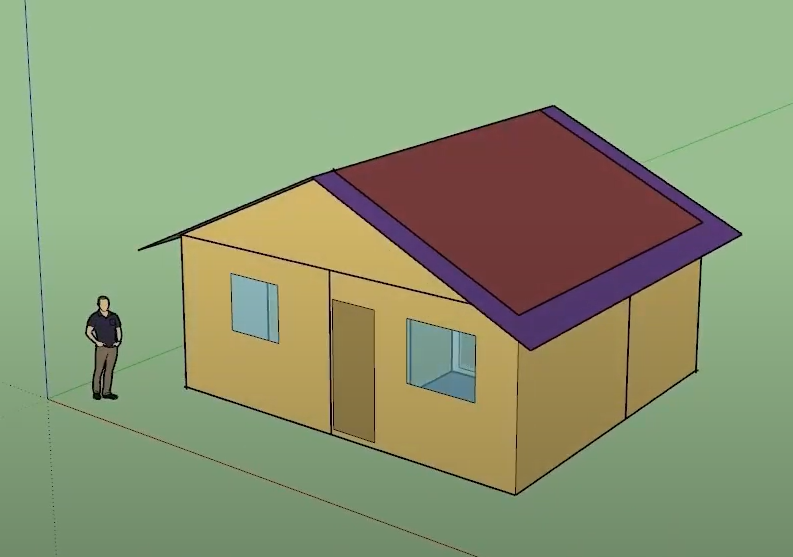

In [18]:
from PIL import Image
from IPython.display import display
from pathlib import Path

# Using Path for full compatibility between Windows and Linux
image_name = "MCMV.png"
image_path = Path(image_name)

if image_path.exists():
    # Opens and displays the image in the cell output
    print(f"Carregando com sucesso: {image_name}")
    img = Image.open(image_path)
    display(img)
else:
    print(f"Arquivo '{image_name}' não encontrado.")
    print("Dica: Se estiver usando o VS Code conectado ao Colab, clique com o botão direito na imagem local e escolha 'Upload to Colab'.")

### 🌐 Carregando uma Imagem via URL (Multiplataforma)

Embora comandos de terminal como o `!wget` sejam muito comuns em notebooks Colab para baixar arquivos da internet, **eles dão erro no Windows**.

A maneira mais segura e multiplataforma de baixar uma imagem (ou qualquer arquivo) via script é usar o próprio Python. A biblioteca nativa `urllib` ou pacotes como `requests` garantem que o código rode sem modificações em qualquer sistema operacional.

Iniciando download da URL: https://picsum.photos/200/300
Download concluído! Exibindo imagem:


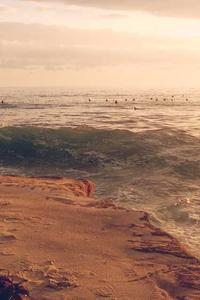

In [19]:
import urllib.request
from PIL import Image
from IPython.display import display
from pathlib import Path

url = "https://picsum.photos/200/300"
output_filename = "imagem_baixada.jpg"

print(f"Iniciando download da URL: {url}")
# urllib.request works natively on Windows, Mac, and Linux (Colab)
urllib.request.urlretrieve(url, output_filename)

if Path(output_filename).exists():
    print("Download concluído! Exibindo imagem:")
    display(Image.open(output_filename))
else:
    print("Houve um problema ao salvar a imagem.")

### 🐍 Verificando a Instalação do `pip` (Multiplataforma)

O `pip` é o gerenciador de pacotes padrão do Python, usado para instalar e gerenciar bibliotecas como `pandas`, `Pillow`, entre outras.

A célula abaixo usa o próprio Python (`sys.executable -m pip`) para verificar a versão do `pip` de forma segura em qualquer sistema operacional (Windows, Linux ou Mac), sem depender exclusivamente de comandos de shell.

In [20]:
import subprocess
import sys

print("--- Verificando a Instalação do pip ---")
try:
    # The most robust and cross-platform way to call pip via script
    # This ensures we are checking the pip associated with the current Python
    result = subprocess.run(
        [sys.executable, "-m", "pip", "--version"],
        capture_output=True,
        text=True,
        check=True
    )
    print("✅ pip encontrado com sucesso!")
    print(f"Detalhes: {result.stdout.strip()}")

except subprocess.CalledProcessError:
    print("❌ pip não foi encontrado.")
    if sys.platform.startswith('linux'):
        print("Dica para Linux (Colab/Ubuntu): Descomente e execute o comando abaixo em uma nova célula:")
        print("# !sudo apt-get update && sudo apt-get install python3-pip -y")
    elif sys.platform == 'win32':
        print("Dica para Windows: Verifique se o Python foi adicionado ao 'PATH' durante a instalação local.")
    else:
        print("Consulte a documentação do Python para instalar o pip no seu sistema.")

--- Verificando a Instalação do pip ---
✅ pip encontrado com sucesso!
Detalhes: pip 26.0.1 from c:\Users\joaop\Documents\Google-Automation-Labs\.venv\Lib\site-packages\pip (python 3.13)


### 📊 Criando e Manipulando DataFrames com Pandas

O `pandas` é uma das ferramentas mais poderosas para análise de dados em Python. A principal estrutura de dados é o **DataFrame**, que funciona como uma tabela.

Abaixo, criamos um DataFrame simples a partir de um dicionário Python e usamos a função `display()` para renderizá-lo de forma amigável no notebook.

### 📦 Gerenciamento de Dependências (requirements.txt)

Em projetos Python, as bibliotecas necessárias devem ser listadas em um arquivo `requirements.txt` na raiz do projeto.
* **No Google Colab:** Bibliotecas populares como o `pandas` já vêm pré-instaladas.
* **No VS Code (Local):** Se você estiver usando um ambiente virtual (`venv`), precisará instalar essas dependências manualmente usando `pip install -r requirements.txt` ou instalando pacote por pacote.

In [13]:
try:
    import pandas as pd
    print("✅ Pandas importado com sucesso!")
except ImportError:
    print("❌ Pandas não encontrado.")
    print("Se estiver rodando localmente (VS Code), instale com: pip install pandas")
    print("Se estiver no Colab, rode em outra célula: !pip install pandas")

✅ Pandas importado com sucesso!


In [21]:
import pandas as pd
from IPython.display import display

data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35]
}

print("Tipo de dado original:", type(data))

# Converting the dictionary to a DataFrame and setting indices
visitors = pd.DataFrame(data, index=['Visitor1', 'Visitor2', 'Visitor3'])

print("\nVisualização do DataFrame:")
display(visitors)

Tipo de dado original: <class 'dict'>

Visualização do DataFrame:


,Name,Age
Visitor1,Alice,25
Visitor2,Bob,30
Visitor3,Charlie,35
